In [1]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../shared_utils")
from experiment_utils import manual_filtering


import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Util function 

## Read annotation file

In [3]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Bound dictionary 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Loop over solutions 

In [8]:
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/new_runs_mgkpro")
paths = os.listdir(path_to_results)

In [9]:
cell_types = ["MgkPro"]

In [10]:
pure_cell_type_solution_dict = {cell_type: [] 
                                for cell_type in cell_types
                               }

for experiment_folder in tqdm(paths):
    # Only consider pure populations 
    if "pure" in experiment_folder:
        cell_type_file_paths = path_to_results / experiment_folder
        # For all cell types 
        for cell_type in os.listdir(cell_type_file_paths):
            if cell_type=="MgkPro":
                config_exp_folders = cell_type_file_paths / cell_type
                # For all the experiments in the folders 
                for config_exp_folder in os.listdir(config_exp_folders):
                    # Be sure candidates are there 
                    if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                        candidate_path = config_exp_folders / config_exp_folder / "candidates.csv"
                        candidate_df = pd.read_csv(candidate_path)
                        candidate_df["run_name"] = [file.split("/")[-1] for file in candidate_df["cfg:paths:dump_dir"]]
                        pure_cell_type_solution_dict[cell_type].append(candidate_df)

100%|██████████| 6/6 [00:19<00:00,  3.20s/it]


In [11]:
# Concatenate data frame 
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict.items()
}

In [12]:
pure_cell_type_solution_dict_concat["MgkPro"]

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,MgkPro:2026-03-12_17-04-39_221b4785:0,7.126898,0.000000,524.30720,14.310798,0.240438,21.832958,15.099325,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MgkPro:2026-03-12_17-04-39_221b4785:1,14.098056,9.074765,3249.76030,195.162340,0.000000,31.863394,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MgkPro:2026-03-12_17-04-39_221b4785:2,12.130225,0.547647,97.26468,47.630554,6.110730,7.734135,0.000000,2.466211,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MgkPro:2026-03-12_17-04-39_221b4785:3,11.894924,2.152432,567.81890,1.018503,25.047798,7.023629,36.114155,0.106266,2.545905,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MgkPro:2026-03-12_17-04-39_221b4785:4,18.310776,5.893925,81.26710,45.181250,0.000000,18.032204,0.474950,1.604604,4.767726,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,MgkPro:2026-03-12_17-46-28_3c04b980:95,15.537278,0.000000,1129.10190,153.097530,0.000000,13.590465,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,MgkPro:2026-03-12_17-46-28_3c04b980:96,0.609698,0.000000,204.55843,52.408154,0.839969,3.252890,7.866806,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,MgkPro:2026-03-12_17-46-28_3c04b980:97,37.419860,0.000000,1394.03530,54.036810,0.000000,16.242945,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,MgkPro:2026-03-12_17-46-28_3c04b980:98,75.201355,1.416241,285.02176,284.180660,0.289118,31.752111,1.007647,0.777592,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
for col in pure_cell_type_solution_dict_concat["MgkPro"].columns:
    print(col)

sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14-Mono_prop
CD49c-Myeloid_prop
CyclingProgenitor*_prop
DCs-CD14_prop
EarlyGMP_prop
Early_Pro-B_prop
EosBasoMastPre_prop
EosBasoMastPre_2_prop
EryPro_prop
GMP-Cycle_prop
GMP-Neutro_prop
GMP-Neutro/CD16-Mono_prop
HSCs_prop
MEP_prop
MLP_prop
MPP_prop
MgkPro_prop
Pro-B_prop
pDCs/cDCs_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:base_sample_rep
cfg:annotation:scatter_obsm_key
cfg:annotation:concat_

In [14]:
# Cell type fractions
celltype_fraction = {
    "MgkPro": 0.15
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    "loss", 
    # "target_ct_loss_std",
    # "target_ct_loss_mean",
    # "ct_prop_total_variance",
    # "exploitation_score",
    # "exploration_score",
    # "weighted_uncertainty_score",
    # "metric_response_surface"
]

### Filter values

In [15]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [16]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered MgkPro number of solutions: 589
Unfiltered MgkPro number of solutions: 33300 



In [17]:
annotated_df

{'MgkPro':     gm-csf_[ng_ml]  tpo_[ng_ml]    sr1_[nm]  um171_[nm]  um729_[µm]  \
 67       10.008255     0.464849   93.159670    0.009097    0.311442   
 67       10.007412     1.521062   81.766450    0.000000    0.000000   
 67       10.026016     1.374722   75.436520    0.000000    0.000000   
 67       10.012607     1.568790   88.612420    0.000000    0.004937   
 67       10.008223     1.758107  132.320940    0.000000    0.062513   
 ..             ...          ...         ...         ...         ...   
 75        0.000000     0.000000   14.404264   21.452860    0.000000   
 75        0.000000     0.000000   14.404264   21.452860    0.000000   
 56        0.000000    28.357067  128.297120  326.053560    0.521771   
 75        0.000000     0.000000   16.323677   30.458523    0.432003   
 75        0.000000     0.000000   16.323677   30.458523    0.432003   
 
     scf_[ng_ml]  butyzamide_[nm]  retinoic_acid_[µm]  ldl_[ng_ml]  \
 67    10.979758         3.556290            0.544896 

## Downstream

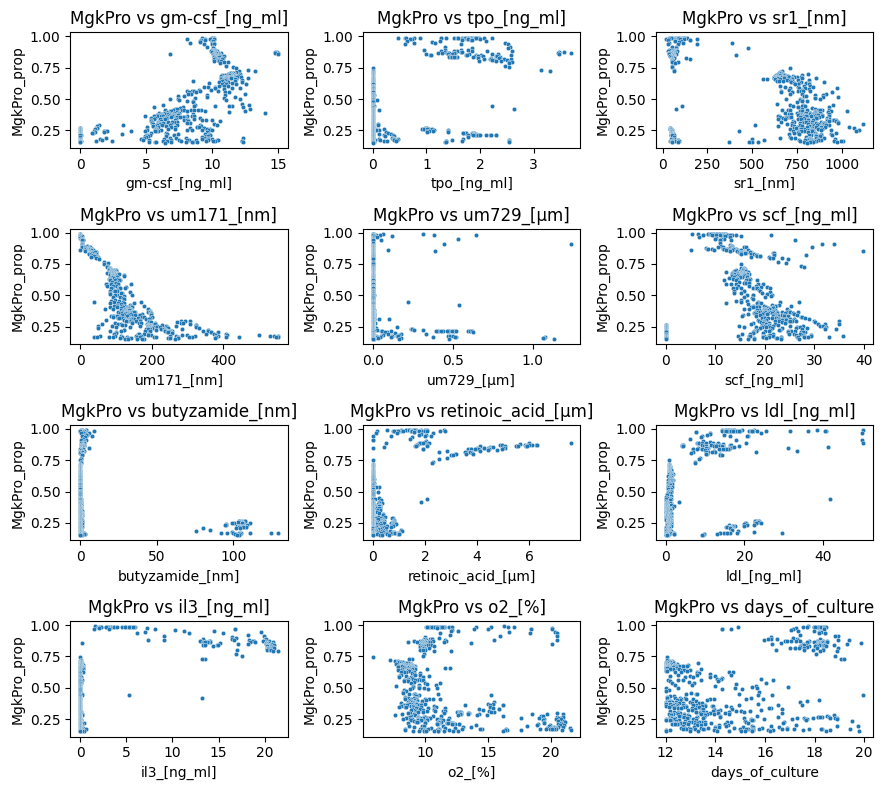

In [20]:
for cell_type in filtered_df:
    # Cell type safe
    cell_type_safe = cell_type.replace(":", "/")
    
    n_params = len(protocol_cols)
    ncols = 3  # adjust as you like
    nrows = math.ceil(n_params / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 2*nrows))
    axes = axes.flatten()  # make indexing easy

    for i, param in enumerate(protocol_cols):
        sns.scatterplot(
            data=filtered_df[cell_type],
            x=param,
            y=f"{cell_type_safe}_prop",
            ax=axes[i], 
            s=10
        )
        axes[i].set_title(f"{cell_type} vs {param}")

    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [23]:
import pickle as pkl 

with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/fitlered_populations_LPH12.pkl", "wb") as file:
    pkl.dump(filtered_df, file)